In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

from scipy.io import arff
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


/home/zahra/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Device: cuda


# Predicting the location of proteins (Protein Localization Sites) within the cell, based on chemical and structural characteristics

## Section 1

In [2]:
data, meta = arff.loadarff('./yeast_dataset.arff')
df = pd.DataFrame(data)

for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].apply(lambda x: x.decode('utf-8'))

print(df.head())
print(df.info())
print(df.describe())


target = df.columns[-1]
features = df.columns[:-1]

X = df[features].values
y = df[target].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

print('X is' , X[:5])
print('y is' , y[:5])


    mcg   gvh   alm   mit  erl  pox   vac   nuc localization_site
0  0.64  0.62  0.49  0.15  0.5  0.0  0.53  0.22               MIT
1  0.58  0.44  0.57  0.13  0.5  0.0  0.54  0.22               NUC
2  0.42  0.44  0.48  0.54  0.5  0.0  0.48  0.22               MIT
3  0.51  0.40  0.56  0.17  0.5  0.5  0.49  0.22               CYT
4  0.50  0.54  0.48  0.65  0.5  0.0  0.53  0.22               MIT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1484 entries, 0 to 1483
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   mcg                1484 non-null   float64
 1   gvh                1484 non-null   float64
 2   alm                1484 non-null   float64
 3   mit                1484 non-null   float64
 4   erl                1484 non-null   float64
 5   pox                1484 non-null   float64
 6   vac                1484 non-null   float64
 7   nuc                1484 non-null   float64
 8   localization_

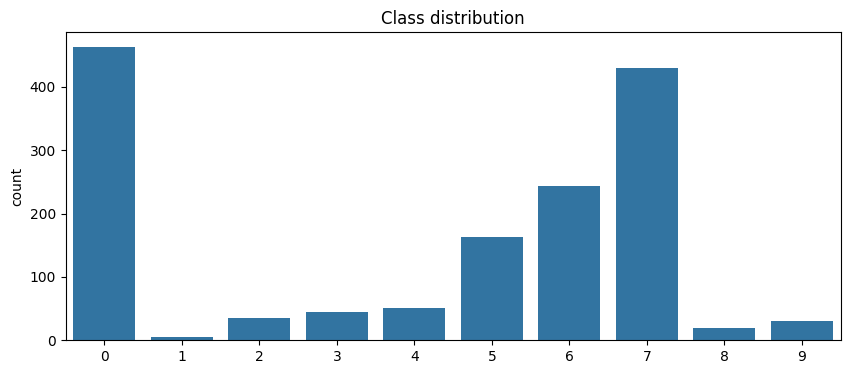

Train: 1038  samples
Val: 223  samples
Test: 223  samples


In [3]:
plt.figure(figsize=(10,4))
sns.countplot(x=y)
plt.title("Class distribution")
plt.show()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print("Train:", len(X_train)," samples")
print("Val:", len(X_val)," samples")
print("Test:", len(X_test)," samples")


## **Analytical Answers – Section 1**

### **1. Do the features need normalization?**  
After examining the dataset statistics using `df.describe()`, it appears that most features are already on roughly similar scales. Their means and standard deviations fall within comparable numerical ranges, which suggests that the dataset is not severely scale‑imbalanced.  

The only noticeable exception is the **pox** feature. Its mean is noticeably smaller compared to the others, which is likely because many samples have pox values close to zero. This difference in scale is not extreme, but it is large enough to potentially influence gradient‑based optimization during neural network training.

For safety, and because neural networks generally benefit from standardized inputs, I used **StandardScaler** to normalize all features. Even if the dataset is “almost” well‑scaled, ensuring a consistent distribution across all features helps stabilize training and usually improves convergence.

---

### **How StandardScaler works**  
`StandardScaler` performs **z-score standardization**, which transforms each feature \( x \) as:

\[
x' = \frac{x - \mu}{\sigma}
\]

where \( \mu \) is the mean of the feature and \( \sigma \) is its standard deviation.  
This transformation produces features with:

- mean ≈ 0  
- standard deviation ≈ 1  

This is particularly helpful for neural networks because it:

- makes optimization landscapes smoother  
- prevents features with larger magnitudes from dominating gradients  
- allows SGD/Adam to converge faster and more reliably  

---

### **How LabelEncoder works**  
`LabelEncoder` is used to convert class labels (initially strings) into integer values. It does this by:

1. Identifying all unique label categories  
2. Assigning each one an integer ID from 0 to C−1  
3. Mapping the original string labels to their corresponding integer ID  

This step is necessary because neural networks expect the target labels in classification tasks to be integer‑encoded class indices.

---

### **2. Is the dataset imbalanced?**  
Yes, the dataset is **moderately imbalanced**.  
Based on the class distribution, the most frequent classes (in decreasing order) are:

1. Class **0**  
2. Class **7**  
3. Class **6**  
4. Class **5**

These classes appear noticeably more often than several others. 
---

### **Why imbalance is a problem without stratification**  

If we split the data into train/validation/test **without** stratification:

#### **1. The validation and test sets may completely miss some rare classes**  
This leads to:

- unreliable performance estimates  
- artificially high accuracy (because majority classes dominate)  
- inability to measure how the model behaves on minority classes  

#### **2. The training set may not contain enough examples of rare classes**  
This causes the model to:

- overfit majority classes  
- fail to learn meaningful decision boundaries for minority classes  
- become biased toward predicting the dominant groups  

#### **3. High variance between runs**  
Since random splitting may place minority classes inconsistently across splits, model performance becomes unstable and non‑reproducible.

---

### **How stratified splitting solves the issue**  
Using `train_test_split(..., stratify=y)` ensures that **each split preserves the overall class distribution of the dataset**.

Internally, scikit‑learn’s stratified splitting works by:

1. Grouping samples by class  
2. Calculating the proportion of each class in the original dataset  
3. Allocating samples to train/validation/test with the **same proportions**  
4. Randomly selecting samples within each class to maintain variability  

This ensures:

- all classes appear in every split  
- minority classes remain represented  
- evaluation metrics become reliable  
- model training is more balanced  
- results are reproducible  

---



## Section 2


In [4]:
batch_size = 32

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size)


In [5]:
class Net(nn.Module):
    def __init__(self, in_dim, h1=64, h2=32, out_dim=10):
        super().__init__()
        self.fc1, self.fc2, self.fc3 = nn.Linear(in_dim, h1), nn.Linear(h1, h2), nn.Linear(h2, out_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # return F.softmax(self.fc3(x), dim=1)
        return self.fc3(x)

In [6]:
def init_weights(model, mode='xavier'):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if mode == 'zero':
                nn.init.constant_(m.weight, 0)
                nn.init.constant_(m.bias, 0)
            elif mode == 'xavier':
                nn.init.xavier_uniform_(m.weight) 
                nn.init.zeros_(m.bias)
            elif mode == 'he':
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
            elif mode == "random":
                nn.init.normal_(m.weight, mean=0.0, std=1.0)
                nn.init.zeros_(m.bias)

In [7]:
def train_eval(init_mode, opt, lr=0.01, epochs=200, lr_decay=False, step_size=15, gamma=0.5):

    model = Net(in_dim=8, out_dim=10)
    init_weights(model, init_mode)
    model.to(device)

    # optimizer
    if opt == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif opt == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    # scheduler
    scheduler = None
    if lr_decay:
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=step_size,
            gamma=gamma
        )

    loss_fn = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    val_f1s = []
    lrs = []

    for epoch in range(epochs):

        model.train()
        epoch_train_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()

            outputs = model(xb)
            loss = loss_fn(outputs, yb)

            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()

        epoch_train_loss /= len(train_loader)
        train_losses.append(epoch_train_loss)



        model.eval()
        val_loss = 0.0
        preds = []
        trgs = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                outputs = model(xb)
                loss = loss_fn(outputs, yb)

                val_loss += loss.item()

                preds += outputs.argmax(dim=1).cpu().tolist()
                trgs += yb.cpu().tolist()

        val_loss /= len(val_loader)

        val_losses.append(val_loss)
        val_f1s.append(f1_score(trgs, preds, average='macro'))

        lrs.append(optimizer.param_groups[0]['lr'])

        # LR decay
        if scheduler is not None:
            scheduler.step()

        if epoch % 10 == 0:
            print(
                f"{init_mode} | {opt.upper()} | Epoch {epoch+1:03d}: "
                f"TrainLoss={train_losses[-1]:.4f}, "
                f"ValLoss={val_losses[-1]:.4f}, "
                f"F1={val_f1s[-1]:.4f}, "
                f"LR={lrs[-1]:.5f}"
            )

    return model, train_losses, val_losses, val_f1s, lrs



zero | ADAM | Epoch 001: TrainLoss=2.1704, ValLoss=2.0551, F1=0.0478, LR=0.01000
zero | ADAM | Epoch 011: TrainLoss=1.7349, ValLoss=1.7356, F1=0.0478, LR=0.01000
zero | ADAM | Epoch 021: TrainLoss=1.7231, ValLoss=1.7321, F1=0.0478, LR=0.01000
zero | ADAM | Epoch 031: TrainLoss=1.7255, ValLoss=1.7319, F1=0.0478, LR=0.01000
zero | ADAM | Epoch 041: TrainLoss=1.7219, ValLoss=1.7320, F1=0.0478, LR=0.01000
zero | ADAM | Epoch 051: TrainLoss=1.7236, ValLoss=1.7321, F1=0.0478, LR=0.01000
zero | ADAM | Epoch 061: TrainLoss=1.7240, ValLoss=1.7320, F1=0.0478, LR=0.01000
zero | ADAM | Epoch 071: TrainLoss=1.7324, ValLoss=1.7322, F1=0.0478, LR=0.01000
zero | ADAM | Epoch 081: TrainLoss=1.7245, ValLoss=1.7323, F1=0.0478, LR=0.01000
zero | ADAM | Epoch 091: TrainLoss=1.7265, ValLoss=1.7325, F1=0.0478, LR=0.01000
zero | ADAM | Epoch 101: TrainLoss=1.7284, ValLoss=1.7324, F1=0.0478, LR=0.01000
zero | ADAM | Epoch 111: TrainLoss=1.7263, ValLoss=1.7324, F1=0.0478, LR=0.01000
zero | ADAM | Epoch 121: Tra

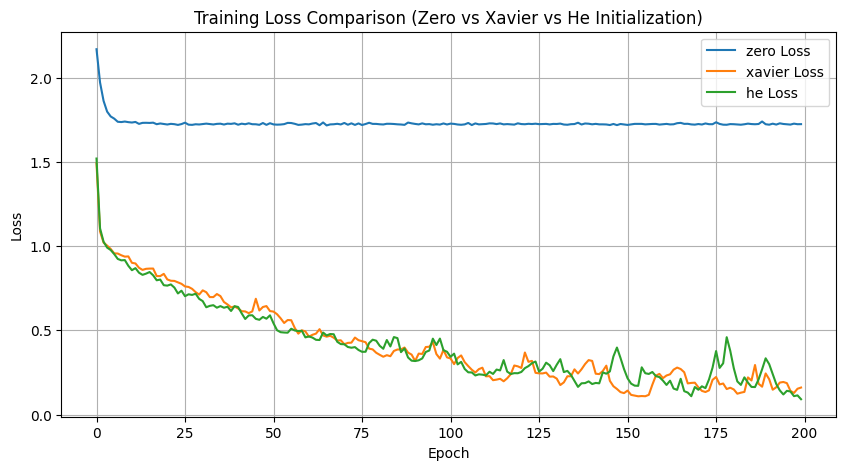

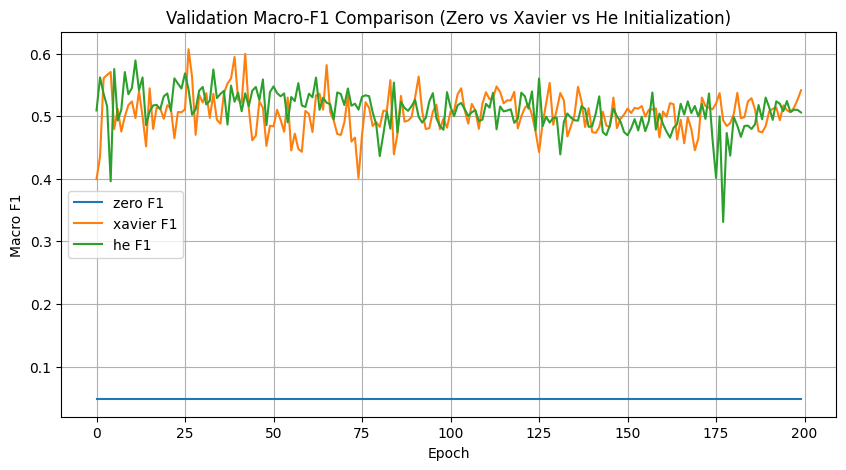

In [8]:
results = {}
for mode in ['zero', 'xavier', 'he']:
    model, tr_loss,va_losses, va_f1 ,lrs= train_eval(mode,'adam')
    results[mode] = {'train_loss': tr_loss, 'val_f1': va_f1}


plt.figure(figsize=(10,5))
for mode in ['zero', 'xavier', 'he']:
    plt.plot(results[mode]['train_loss'], label=f'{mode} Loss')

plt.title('Training Loss Comparison (Zero vs Xavier vs He Initialization)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()



plt.figure(figsize=(10,5))
for mode, his in results.items():
    plt.plot(his['val_f1'], label=f'{mode} F1')
plt.title('Validation Macro-F1 Comparison (Zero vs Xavier vs He Initialization)')
plt.xlabel('Epoch'); plt.ylabel('Macro F1')
plt.legend(); plt.grid(True); plt.show()


## Analytical Answers — Section 2

### Activation Function Choice (ReLU)
In this experiment, the hidden layers use the **ReLU** activation function.  
ReLU is currently the most widely used activation in deep neural networks because of its **non-linearity, computational efficiency**, and ability to **alleviate the vanishing gradient problem**.  
Unlike sigmoid or tanh, which saturate for large input magnitudes and cause gradients to vanish, ReLU keeps gradients alive whenever the input is positive.  
This allows the network to learn faster and to represent more complex relationships in the data.

---

### Softmax at the Output Layer
Since the Yeast dataset involves **multi-class classification**, the final layer must output a probability distribution over all classes.  
This is achieved using the **Softmax** activation function.

It ensures all outputs are positive and sum to one, making them interpretable as class probabilities.

However, in **PyTorch**, the built-in loss function `nn.CrossEntropyLoss()` **expects raw logits**, not softmax probabilities, because it internally applies `log_softmax`.  
Passing already-softmaxed outputs would therefore result in incorrect gradients.  
For this reason, although softmax is conceptually correct for the last layer, in implementation I return **raw logits** and let `CrossEntropyLoss` handle the softmax part internally.

---

### Weight Initialization Comparison
I tested three initialization strategies for the network weights:

1. **Zero Initialization**  
2. **Xavier Initialization**  
3. **He Initialization**

#### Zero Initialization
In **zero initialization**, all weights are set to 0.  
This approach fails to break the symmetry between neurons — every neuron within the same layer receives identical gradients and produces identical activations.  
As a result, they all learn exactly the same function, and the model effectively behaves as if having only one neuron per layer.  
Because all updates remain equal, the weights never diversify, and the network cannot converge.  
Consequently, the loss value remains almost constant throughout training, showing no effective learning and no reduction in error.


#### Xavier (Glorot) Initialization
Xavier initialization (also known as Glorot initialization) randomly sets weights such that the **variance of activations and gradients** remains approximately constant across layers:
$$
Var(W) = \frac{1}{n_{in} + n_{out}}
$$


It is suitable for activation functions like **sigmoid** or **tanh**, where maintaining balanced variance helps prevent both vanishing and exploding gradients.  
In my network, Xavier initialization produced significantly lower loss and better convergence than zero initialization.

#### He (Kaiming) Initialization
He initialization is specifically designed for **ReLU** activations:
$$
Var(W) = \frac{2}{n_{in}}
$$
Because ReLU only activates roughly half of its inputs, the variance needs to be larger to keep output magnitudes stable.  
He initialization maintains a good balance between stability and gradient flow, leading to faster convergence and lower final loss values in networks using ReLU layers.

---



## Section 3

he | SGD | Epoch 001: TrainLoss=1.7912, ValLoss=1.4223, F1=0.2683, LR=0.01000
he | SGD | Epoch 011: TrainLoss=0.9509, ValLoss=1.1132, F1=0.5116, LR=0.01000
he | SGD | Epoch 021: TrainLoss=0.8907, ValLoss=1.1604, F1=0.5355, LR=0.01000
he | SGD | Epoch 031: TrainLoss=0.8344, ValLoss=1.2800, F1=0.5420, LR=0.01000
he | SGD | Epoch 041: TrainLoss=0.8031, ValLoss=1.2655, F1=0.5218, LR=0.01000
he | SGD | Epoch 051: TrainLoss=0.7348, ValLoss=1.3049, F1=0.4882, LR=0.01000
he | SGD | Epoch 061: TrainLoss=0.7178, ValLoss=1.3935, F1=0.5086, LR=0.01000
he | SGD | Epoch 071: TrainLoss=0.7179, ValLoss=1.4557, F1=0.5688, LR=0.01000
he | SGD | Epoch 081: TrainLoss=0.6444, ValLoss=1.4121, F1=0.5425, LR=0.01000
he | SGD | Epoch 091: TrainLoss=0.6143, ValLoss=1.5204, F1=0.5188, LR=0.01000
he | ADAM | Epoch 001: TrainLoss=1.4879, ValLoss=1.2724, F1=0.4568, LR=0.01000
he | ADAM | Epoch 011: TrainLoss=0.8740, ValLoss=1.1779, F1=0.5487, LR=0.01000
he | ADAM | Epoch 021: TrainLoss=0.7362, ValLoss=1.3690, F1=0.

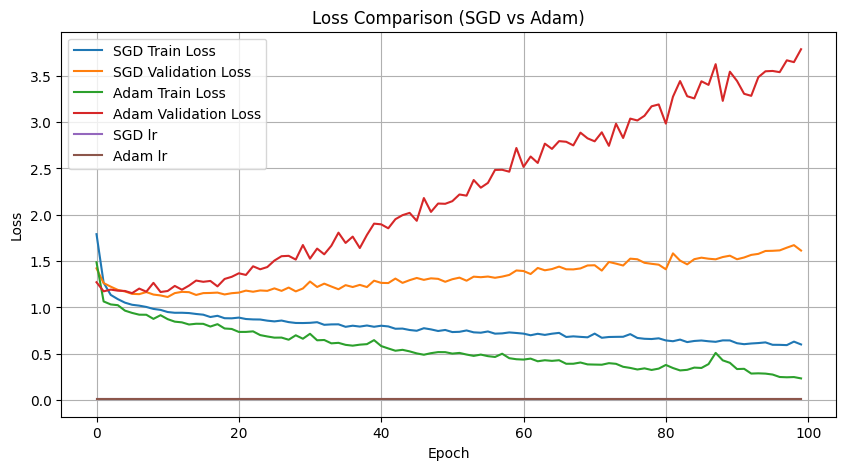

In [9]:
model1, tr_loss1,va_loss1, va_f1 ,lrs1= train_eval('he', 'sgd', lr=0.01, epochs=100)
model2, tr_loss2,va_loss2, va_f1 ,lrs2= train_eval('he', 'adam', lr=0.01, epochs=100)

plt.figure(figsize=(10,5))
plt.plot(tr_loss1, label=f'SGD Train Loss')
plt.plot(va_loss1, label=f'SGD Validation Loss')
plt.plot(tr_loss2, label=f'Adam Train Loss')
plt.plot(va_loss2, label=f'Adam Validation Loss')
plt.plot(lrs1,label='SGD lr')
plt.plot(lrs2,label='Adam lr')

plt.title('Loss Comparison (SGD vs Adam)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


he | SGD | Epoch 001: TrainLoss=2.1734, ValLoss=1.4052, F1=0.2879, LR=0.01000
he | SGD | Epoch 011: TrainLoss=0.9482, ValLoss=1.1001, F1=0.5837, LR=0.00900
he | SGD | Epoch 021: TrainLoss=0.8811, ValLoss=1.1538, F1=0.5702, LR=0.00810
he | SGD | Epoch 031: TrainLoss=0.8302, ValLoss=1.1455, F1=0.5837, LR=0.00729
he | SGD | Epoch 041: TrainLoss=0.7910, ValLoss=1.2057, F1=0.5761, LR=0.00656
he | SGD | Epoch 051: TrainLoss=0.7499, ValLoss=1.2493, F1=0.6253, LR=0.00590
he | SGD | Epoch 061: TrainLoss=0.7237, ValLoss=1.2748, F1=0.5930, LR=0.00531
he | SGD | Epoch 071: TrainLoss=0.7059, ValLoss=1.3164, F1=0.6104, LR=0.00478
he | SGD | Epoch 081: TrainLoss=0.6689, ValLoss=1.3303, F1=0.5933, LR=0.00430
he | SGD | Epoch 091: TrainLoss=0.6521, ValLoss=1.3612, F1=0.5937, LR=0.00387
he | ADAM | Epoch 001: TrainLoss=1.5453, ValLoss=1.2314, F1=0.3596, LR=0.01000
he | ADAM | Epoch 011: TrainLoss=0.8852, ValLoss=1.2357, F1=0.4971, LR=0.00900
he | ADAM | Epoch 021: TrainLoss=0.7719, ValLoss=1.3333, F1=0.

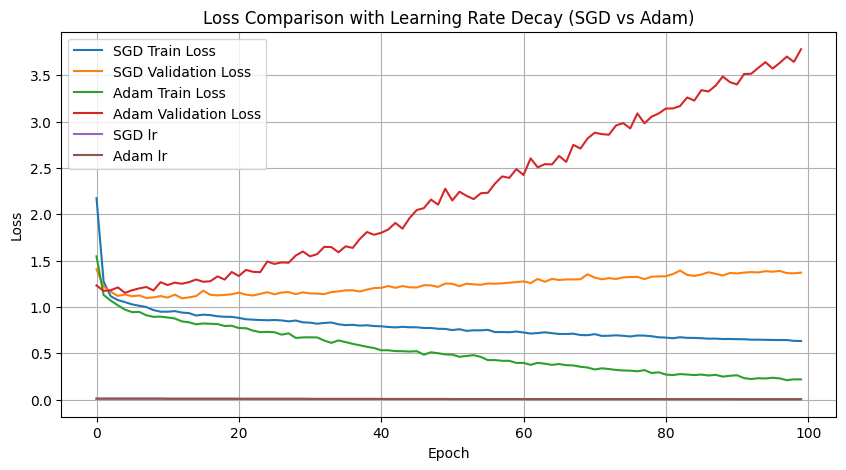

In [10]:
model1, tr_loss1,va_loss1, va_f1,lrs1 = train_eval('he', 'sgd', lr=0.01, epochs=100, lr_decay=True , step_size=10, gamma=0.9)
model2, tr_loss2,va_loss2, va_f1,lrs2 = train_eval('he', 'adam', lr=0.01, epochs=100, lr_decay=True , step_size=10, gamma=0.9)

plt.figure(figsize=(10,5))
plt.plot(tr_loss1, label=f'SGD Train Loss')
plt.plot(va_loss1, label=f'SGD Validation Loss')
plt.plot(tr_loss2, label=f'Adam Train Loss')
plt.plot(va_loss2, label=f'Adam Validation Loss')
plt.plot(lrs1,label='SGD lr')
plt.plot(lrs2,label='Adam lr')

plt.title('Loss Comparison with Learning Rate Decay (SGD vs Adam)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Analytical Answers — Section 3

## **1. Comparison Between Adam and SGD**

From the loss curves, it is clear that **Adam converges substantially faster than SGD**.  
This is consistent with the theoretical properties of the optimizer:

- **SGD** updates the parameters using a single global learning rate and the (possibly noisy) estimate of the gradient. As a result, its progress can be slow, especially in regions where the curvature of the loss landscape is different across dimensions.

- **Adam**, on the other hand, adaptively rescales the gradient for each parameter using running estimates of both the **mean** and the **variance** of the gradients.  
  Scientifically, this allows Adam to:
  - take larger steps in directions where the gradient is consistently small,
  - take smaller steps in directions with high curvature,

Because of these adaptive updates, Adam typically **reaches a good region of the parameter space much earlier**, whereas SGD tends to oscillate more and requires more epochs to stabilize.  

---

## **2. Learning Rate Decay Using StepLR**

To study the effect of decaying the learning rate, I used PyTorch’s **StepLR** scheduler.  
The StepLR rule is:

$$\text{lr}_{t} = \text{lr}_{0} \times \gamma^{\lfloor t / \text{step\_size} \rfloor}$$

This means:
- The learning rate remains constant for a number of epochs (`step_size`).
- After every `step_size` epochs, the lr is multiplied by `gamma` (usually a value less than 1).
- This produces a **piecewise‑constant, staircase‑shaped** learning rate schedule.

Conceptually, StepLR allows the model to:
1. **Explore the loss landscape more aggressively** during early training.
2. Then **make more precise, smaller adjustments** later on, when the weights are closer to good local minima.

---

## **3. Observed Effects of Applying LR Decay**

When comparing the models trained **with** and **without** StepLR, a consistent pattern appears:

### **A reduction in loss oscillations during the later epochs.**

This effect is expected, and its cause is straightforward:

- In early epochs, the learning rate is relatively large, which makes the optimizer jump farther in parameter space.  
  This is useful for exploration but introduces noise in the loss curve.
- After the learning rate decays, each update becomes smaller and more controlled.

In other words, StepLR causes the optimization trajectory to “cool down” gradually.  

---


## Section 4

In [11]:
class Net2(nn.Module):
    def __init__(self, in_dim=8, hidden=64, out_dim=10, dropout_p=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden, out_dim)
        )

    def forward(self, x):
        return self.net(x)

In [12]:
def train_eval2(init_mode,
                   opt='adam',
                   lr=0.01,
                   epochs=200,
                   dropout_p=0.0,
                   weight_decay=0.0,
                   l1_lambda=0.0,
                   early_stop=False,
                   patience=20):

    model = Net2(in_dim=8, out_dim=10, dropout_p=dropout_p)
    init_weights(model, init_mode)
    model.to(device)

    if opt == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)

    loss_fn = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []
    train_accs, val_accs = [],[]

    best_val = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)

            # L1 regularization
            if l1_lambda > 0:
                l1 = sum(p.abs().sum() for p in model.parameters())
                loss += l1_lambda * l1

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            pred = out.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)

        train_losses.append(epoch_loss / len(train_loader))
        train_accs.append(correct / total)


        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)

                out = model(xb)
                loss = loss_fn(out, yb)

                val_loss += loss.item()
                pred = out.argmax(1)
                correct += (pred == yb).sum().item()
                total += yb.size(0)

        val_loss /= len(val_loader)

        val_losses.append(val_loss)
        val_accs.append(correct / total)

        # early stopping
        if early_stop:
            if val_loss < best_val:
                best_val = val_loss
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print("Early stopping at epoch", epoch+1)
                break

        if epoch % 20 == 0:
            print(f"Epoch {epoch+1} | TrainAcc={train_accs[-1]:.3f} | ValAcc={val_accs[-1]:.3f}")

    return model, train_losses, val_losses, train_accs, val_accs


In [13]:
model_base, tr0, va0, acc_tr0, acc_va0 = train_eval2(
    'he',
    opt='adam',
    lr=0.01,
    epochs=300,
    dropout_p=0.0,
    weight_decay=0.0,
    l1_lambda=0.0,
    early_stop=False
)

model_l2, tr_l2, va_l2, acc_tr_l2, acc_va_l2 = train_eval2(
    'he',
    opt='adam',
    lr=0.005,
    epochs=300,
    dropout_p=0.0,
    weight_decay=1e-2,
    l1_lambda=0.0,
    early_stop=False
)

model_l1, tr_l1, va_l1, acc_tr_l1, acc_va_l1 = train_eval2(
    'he',
    opt='adam',
    lr=0.005,
    epochs=300,
    dropout_p=0.0,
    weight_decay=0.0,
    l1_lambda=0.01,
    early_stop=False
)

model_do, tr_do, va_do, acc_tr_do, acc_va_do = train_eval2(
    'he',
    opt='adam',
    lr=0.01,
    epochs=300,
    dropout_p=0.5,
    weight_decay=0.0,
    l1_lambda=0.0,
    early_stop=False
)

model_es, tr_es, va_es, acc_tr_es, acc_va_es = train_eval2(
    'he',
    opt='adam',
    lr=0.01,
    epochs=300,
    dropout_p=0.0,
    weight_decay=0.0,
    l1_lambda=0.0,
    early_stop=True,
    patience=10
)


Epoch 1 | TrainAcc=0.506 | ValAcc=0.556
Epoch 21 | TrainAcc=0.726 | ValAcc=0.511
Epoch 41 | TrainAcc=0.817 | ValAcc=0.493
Epoch 61 | TrainAcc=0.840 | ValAcc=0.520
Epoch 81 | TrainAcc=0.923 | ValAcc=0.511
Epoch 101 | TrainAcc=0.958 | ValAcc=0.520
Epoch 121 | TrainAcc=0.878 | ValAcc=0.502
Epoch 141 | TrainAcc=0.992 | ValAcc=0.534
Epoch 161 | TrainAcc=0.947 | ValAcc=0.556
Epoch 181 | TrainAcc=1.000 | ValAcc=0.516
Epoch 201 | TrainAcc=0.937 | ValAcc=0.525
Epoch 221 | TrainAcc=0.999 | ValAcc=0.543
Epoch 241 | TrainAcc=1.000 | ValAcc=0.538
Epoch 261 | TrainAcc=0.933 | ValAcc=0.529
Epoch 281 | TrainAcc=0.993 | ValAcc=0.543
Epoch 1 | TrainAcc=0.487 | ValAcc=0.516
Epoch 21 | TrainAcc=0.625 | ValAcc=0.552
Epoch 41 | TrainAcc=0.626 | ValAcc=0.574
Epoch 61 | TrainAcc=0.638 | ValAcc=0.565
Epoch 81 | TrainAcc=0.642 | ValAcc=0.578
Epoch 101 | TrainAcc=0.628 | ValAcc=0.574
Epoch 121 | TrainAcc=0.633 | ValAcc=0.583
Epoch 141 | TrainAcc=0.639 | ValAcc=0.574
Epoch 161 | TrainAcc=0.642 | ValAcc=0.570
Epoc

In [14]:
def plot_overfitting(train_losses, val_losses, train_accs, val_accs, title="Model"):
    epochs = np.arange(1, len(train_losses) + 1)


    best_epoch = int(np.argmin(val_losses)) + 1  

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.axvline(best_epoch, color='red', linestyle='--',
                label=f'Overfitting starts @ epoch {best_epoch}')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss Curves")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label='Train Acc')
    plt.plot(epochs, val_accs, label='Val Acc')
    plt.axvline(best_epoch, color='red', linestyle='--',
                label=f'Overfitting starts @ epoch {best_epoch}')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy Curves")
    plt.legend()

    plt.show()

    print(f"Best epoch (minimum val loss): {best_epoch}")


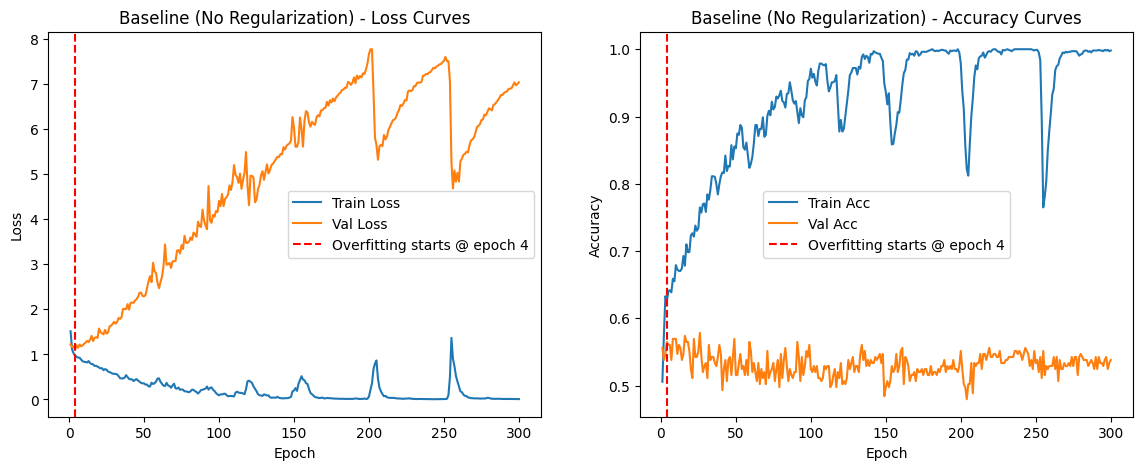

Best epoch (minimum val loss): 4


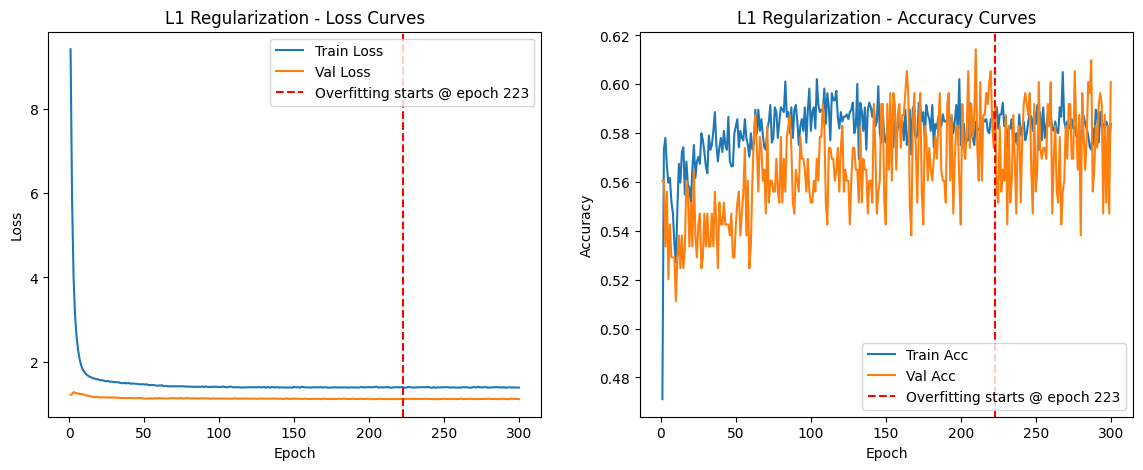

Best epoch (minimum val loss): 223


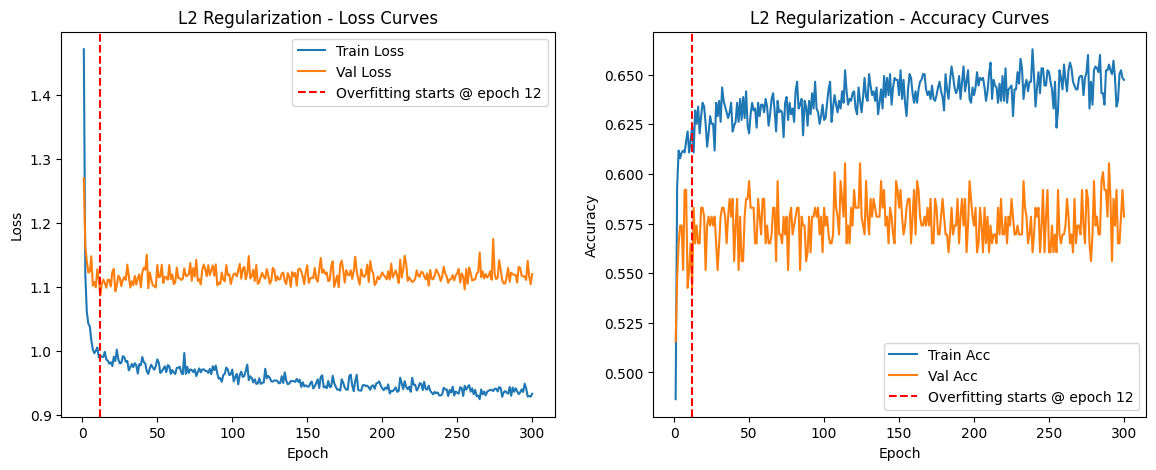

Best epoch (minimum val loss): 12


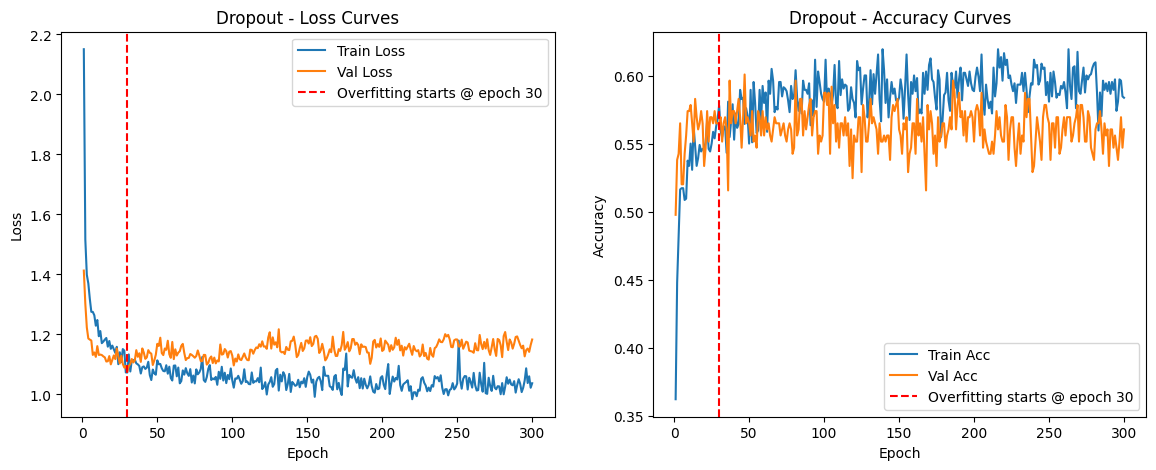

Best epoch (minimum val loss): 30


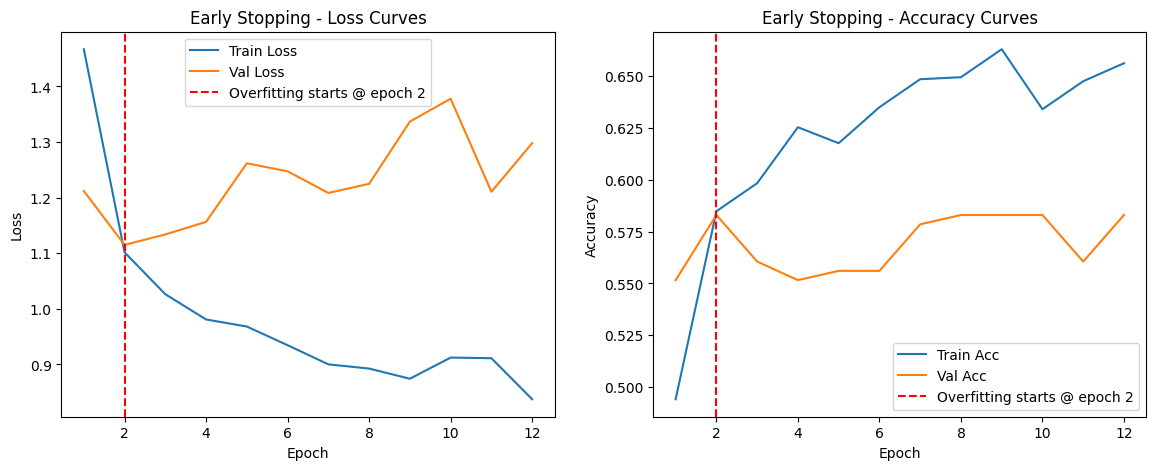

Best epoch (minimum val loss): 2


In [15]:
plot_overfitting(tr0, va0, acc_tr0, acc_va0, title="Baseline (No Regularization)")
plot_overfitting(tr_l1, va_l1, acc_tr_l1, acc_va_l1, title="L1 Regularization")
plot_overfitting(tr_l2, va_l2, acc_tr_l2, acc_va_l2, title="L2 Regularization")
plot_overfitting(tr_do, va_do, acc_tr_do, acc_va_do, title="Dropout")
plot_overfitting(tr_es, va_es, acc_tr_es, acc_va_es, title="Early Stopping")


Regularization significantly improved the model’s generalization. After applying L1, L2, Dropout, and Early Stopping with appropriately tuned coefficients, the gap between training and validation accuracy noticeably decreased. These methods prevented the model from memorizing the training data and reduced overfitting.

## Section 5

In [16]:
class Net_NoBN(nn.Module):
    def __init__(self, input_dim=8, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)


class Net_BN(nn.Module):
    def __init__(self, input_dim=8, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [17]:
def train_model(model, train_loader, val_loader, epochs=50, lr=0.01):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # Train
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                val_loss += criterion(out, yb).item()

        val_losses.append(val_loss / len(val_loader))

    return train_losses, val_losses

In [18]:
# Model WITHOUT BatchNorm
model_no_bn = Net_NoBN()
init_weights(model_no_bn, mode="random")
loss_no_bn_train, loss_no_bn_val = train_model(
    model_no_bn, train_loader, val_loader
)

# Model WITH BatchNorm
model_bn = Net_BN()
init_weights(model_bn, mode="random")
loss_bn_train, loss_bn_val = train_model(
    model_bn, train_loader, val_loader
)

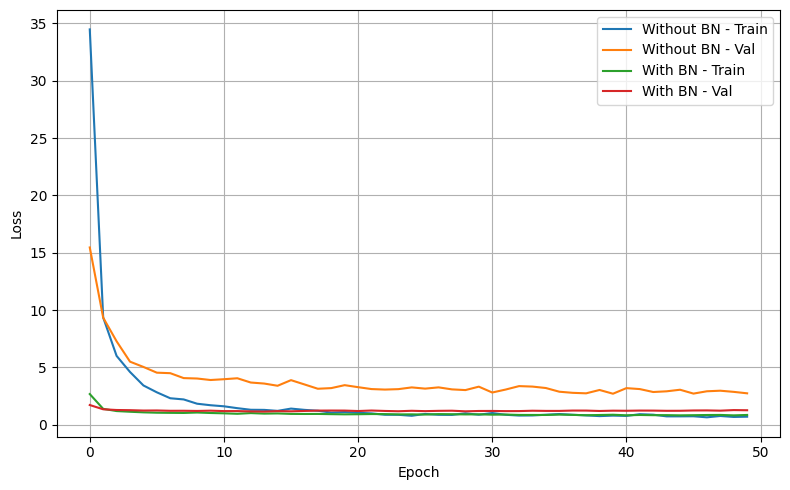

In [19]:
plt.figure(figsize=(8,5))
plt.plot(loss_no_bn_train, label="Without BN - Train")
plt.plot(loss_no_bn_val, label="Without BN - Val")
plt.plot(loss_bn_train, label="With BN - Train")
plt.plot(loss_bn_val, label="With BN - Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

std (without BN) is [0.04194342 0.00789024 0.01047281 0.01575485 0.01190843 0.01361024
 0.01367587 0.01305461 0.0138925  0.00784324 0.0080833  0.0094462
 0.01195664 0.01314295 0.00895437 0.00822096 0.01243267 0.010672
 0.01341076 0.01551319 0.01854696 0.01808104 0.01825216 0.01462657
 0.0175137  0.01662599 0.01943307 0.01975078 0.02062254 0.01821402
 0.01710843 0.01768385 0.02743644 0.02443673 0.0161803  0.01327704
 0.02179381 0.02020821 0.01667357 0.02051307 0.02209666 0.03049108
 0.03610581 0.03519723 0.02862684 0.02146497 0.02782382 0.03864332
 0.03260811 0.0376996 ]
std (with BN) is [0.04660299 0.0172278  0.01538764 0.0119327  0.01429303 0.01579107
 0.01580679 0.01293355 0.00944092 0.01745868 0.0070856  0.01216046
 0.00905661 0.01585446 0.01220073 0.01766107 0.01908124 0.01805136
 0.01455006 0.01071775 0.01069351 0.01910578 0.02497857 0.01781655
 0.02810798 0.01390806 0.01612854 0.01365163 0.01368095 0.01822003
 0.01207034 0.01422842 0.01286059 0.01254307 0.022956   0.01240909
 0.0

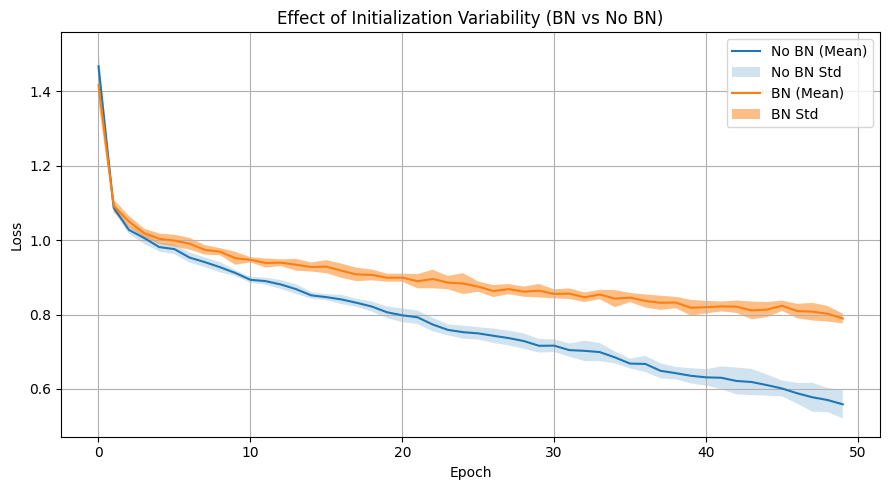

In [26]:
def train_single(model, train_loader, epochs=30, lr=0.01):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()

    loss_list = []

    for ep in range(epochs):
        model.train()
        total = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb)
            loss = crit(out, yb)
            loss.backward()
            opt.step()
            total += loss.item()
        loss_list.append(total / len(train_loader))

    return loss_list


# Multiple initializations
runs = 10
epochs = 50

loss_no_bn_runs = []
loss_bn_runs = []

for r in range(runs):
    model1 = Net_NoBN(8,10)
    model2 = Net_BN(8,10)

    init_weights(model1)
    init_weights(model2)

    loss1 = train_single(model1, train_loader, epochs)
    loss2 = train_single(model2, train_loader, epochs)

    loss_no_bn_runs.append(loss1)
    loss_bn_runs.append(loss2)

loss_no_bn_runs = np.array(loss_no_bn_runs)
loss_bn_runs = np.array(loss_bn_runs)


plt.figure(figsize=(9,5))

mean_no = loss_no_bn_runs.mean(axis=0)
std_no  = loss_no_bn_runs.std(axis=0)
print('std (without BN) is' , std_no)

mean_bn = loss_bn_runs.mean(axis=0)
std_bn  = loss_bn_runs.std(axis=0)
print('std (with BN) is' , std_bn)

plt.plot(mean_no, label="No BN (Mean)")
plt.fill_between(range(epochs), mean_no-std_no, mean_no+std_no,
                 alpha=0.2, label="No BN Std")

plt.plot(mean_bn, label="BN (Mean)")
plt.fill_between(range(epochs), mean_bn-std_bn, mean_bn+std_bn,
                 alpha=0.5, label="BN Std")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.title("Effect of Initialization Variability (BN vs No BN)")
plt.tight_layout()
plt.show()


## Analytical Answers — Section 5

The plotted loss curves allow us to directly compare the behavior of the model **with** and **without** Batch Normalization under the same random initialization conditions. The results clearly show that adding Batch Normalization makes the model significantly **more stable and less sensitive to the choice of initial weights**.

First, we observe that the model **without Batch Normalization** exhibits larger fluctuations during both training and validation. The training loss begins at a very high value and decreases rapidly, but the validation loss remains noticeably unstable for many epochs. This indicates that the optimization dynamics are strongly influenced by the initial randomly assigned weights. In other words, small differences in initialization can cause the activations to shift unpredictably across layers, leading to inconsistent gradients and unstable convergence behavior.

In contrast, the model **with Batch Normalization** shows smooth, well‑behaved loss curves from the very first epoch. Both the training and validation losses start at much lower values and decrease in a stable and controlled manner. There are no large oscillations, and the gap between training and validation loss remains consistently small. This behavior indicates that the internal representations of the network are being normalized at each layer, which reduces the effect of internal covariate shift. As a result, the optimization process becomes far less dependent on the exact values of the initial weights.

Also we observe **lower loss std** (across multiple initialization) when we use batch normalization. This fact indicates more robustness to random weight initialization.

These observations collectively demonstrate that Batch Normalization increases the model’s **robustness** to random weight initialization. "Robustness" here means that the model behaves similarly and converges reliably regardless of how the weights are initialized. With BN, the network is not heavily influenced by the scale or distribution of the initial parameters because each batch is normalized during forward propagation. This makes the optimization landscape smoother and gradients more predictable.

---

## Section 6

In [21]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(weights, dtype=torch.float).to(device)

print(class_weights)

tensor([ 0.3204, 34.6000,  4.3250,  3.3484,  2.8833,  0.9105,  0.6070,  0.3460,
         7.4143,  4.9429], device='cuda:0')


In [22]:
def sample_log_uniform(low, high):
    #sample from log-uniform distribution between low and high
    log_low = np.log10(low)
    log_high = np.log10(high)
    return 10 ** random.uniform(log_low, log_high)

def sample_int_log_uniform(low, high):
    #log-uniform but returning integer neurons
    return int(sample_log_uniform(low, high))

def sample_int_uniform(low, high):
    return random.randint(low, high)

def sample_uniform(low, high):
    return random.uniform(low, high)



# Dynamic Model Builder
class DynamicNet(nn.Module):
    def __init__(self, input_dim, num_classes, num_layers, neurons_list, dropout):
        super().__init__()

        layers = []
        in_dim = input_dim

        for i in range(num_layers):
            out_dim = neurons_list[i]
            layers.append(nn.Linear(in_dim, out_dim))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = out_dim

        layers.append(nn.Linear(in_dim, num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)



def train_and_eval(model, train_loader, val_loader, lr, l2, epochs=40):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=l2)
    criterion = nn.CrossEntropyLoss()

    for ep in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            opt.step()


    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            out = model(xb)
            p = out.argmax(1).cpu().numpy()
            preds.extend(p)
            trues.extend(yb.numpy())

    f1 = f1_score(trues, preds, average='macro')
    acc = accuracy_score(trues, preds)

    return f1, acc



# Random Search
SEARCH_ITERS = 50

best_f1 = -1
best_config = None
best_model_state = None

for i in range(SEARCH_ITERS):
    # Hyperparameter Sampling 
    lr       = sample_log_uniform(1e-4, 1e-1)
    l2       = sample_log_uniform(1e-7, 1e-1)
    dropout  = sample_uniform(0.0, 0.7)

    batch    = sample_int_log_uniform(16, 256)

    num_layers = sample_int_uniform(1, 5)

    neurons_list = [sample_int_log_uniform(8, 512) for _ in range(num_layers)]

    # Build loaders
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size)

    # Build model
    model = DynamicNet(
        input_dim=8,
        num_classes=10,
        num_layers=num_layers,
        neurons_list=neurons_list,
        dropout=dropout
    )

    # Evaluate
    f1, acc = train_and_eval(model, train_loader, val_loader, lr, l2)

    print(f"\nTrial {i+1}/{SEARCH_ITERS}:")
    print("Layers:", num_layers)
    print("Neurons:", neurons_list)
    print(f"LR={lr:.6f}  L2={l2:.7f}  Dropout={dropout:.3f}  Batch={batch}")
    print(f"--> F1={f1:.4f}, Acc={acc:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_config = {
            "lr": lr,
            "l2": l2,
            "dropout": dropout,
            "batch": batch,
            "num_layers": num_layers,
            "neurons_list": neurons_list
        }
        best_model_state = model.state_dict()



print("\nBEST CONFIG FOUND:")
print(best_config)
print("Best F1 on Validation:", best_f1)


# Train Final Model with best hyperparameters
best_batch = best_config["batch"],

X_full = torch.cat([X_train_t, X_val_t], dim=0)
y_full = torch.cat([y_train_t, y_val_t], dim=0)

loader_final = DataLoader(
    TensorDataset(X_full, y_full),
    batch_size=batch_size,
    shuffle=True
)


final_model = DynamicNet(
    input_dim=8,
    num_classes=10,
    num_layers=best_config["num_layers"],
    neurons_list=best_config["neurons_list"],
    dropout=best_config["dropout"]
).to(device)

final_model.load_state_dict(best_model_state)

opt = optim.Adam(final_model.parameters(),
                 lr=best_config["lr"],
                 weight_decay=best_config["l2"])
crit = nn.CrossEntropyLoss()

for ep in range(40):
    final_model.train()
    for xb, yb in loader_final:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        out = final_model(xb)
        loss = crit(out, yb)
        loss.backward()
        opt.step()



# Evaluation on test data
final_model.eval()
preds = []
trues = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = final_model(xb)
        preds.extend(out.argmax(1).cpu().numpy())
        trues.extend(yb.numpy())

test_acc = accuracy_score(trues, preds)
test_f1  = f1_score(trues, preds, average="macro")

print("\nFINAL TEST RESULTS ")
print("Test Accuracy:", test_acc)
print("Test Macro F1:", test_f1)



Trial 1/50:
Layers: 1
Neurons: [133]
LR=0.008285  L2=0.0000001  Dropout=0.193  Batch=29
--> F1=0.5294, Acc=0.5695

Trial 2/50:
Layers: 2
Neurons: [21, 97]
LR=0.047483  L2=0.0000003  Dropout=0.295  Batch=17
--> F1=0.2508, Acc=0.5067

Trial 3/50:
Layers: 4
Neurons: [92, 231, 8, 228]
LR=0.004828  L2=0.0019775  Dropout=0.491  Batch=51
--> F1=0.2672, Acc=0.4798

Trial 4/50:
Layers: 3
Neurons: [12, 38, 35]
LR=0.012428  L2=0.0000110  Dropout=0.109  Batch=227
--> F1=0.5376, Acc=0.5695

Trial 5/50:
Layers: 1
Neurons: [457]
LR=0.001076  L2=0.0000039  Dropout=0.030  Batch=57
--> F1=0.6161, Acc=0.5695

Trial 6/50:
Layers: 3
Neurons: [88, 149, 9]
LR=0.001366  L2=0.0002052  Dropout=0.581  Batch=88
--> F1=0.2958, Acc=0.5471

Trial 7/50:
Layers: 1
Neurons: [38]
LR=0.000483  L2=0.0000054  Dropout=0.056  Batch=30
--> F1=0.5462, Acc=0.5695

Trial 8/50:
Layers: 3
Neurons: [148, 137, 10]
LR=0.002292  L2=0.0101079  Dropout=0.114  Batch=42
--> F1=0.3574, Acc=0.5426

Trial 9/50:
Layers: 3
Neurons: [490, 114,

## Section 7

Final Test Accuracy: 0.6278026905829597

Classification Report

              precision    recall  f1-score   support

           0     0.5843    0.7536    0.6582        69
           1     1.0000    1.0000    1.0000         1
           2     1.0000    0.8000    0.8889         5
           3     0.7500    0.4286    0.5455         7
           4     0.1667    0.1250    0.1429         8
           5     0.7857    0.8800    0.8302        25
           6     0.6061    0.5556    0.5797        36
           7     0.6415    0.5231    0.5763        65
           8     1.0000    1.0000    1.0000         3
           9     0.0000    0.0000    0.0000         4

    accuracy                         0.6278       223
   macro avg     0.6534    0.6066    0.6222       223
weighted avg     0.6236    0.6278    0.6184       223



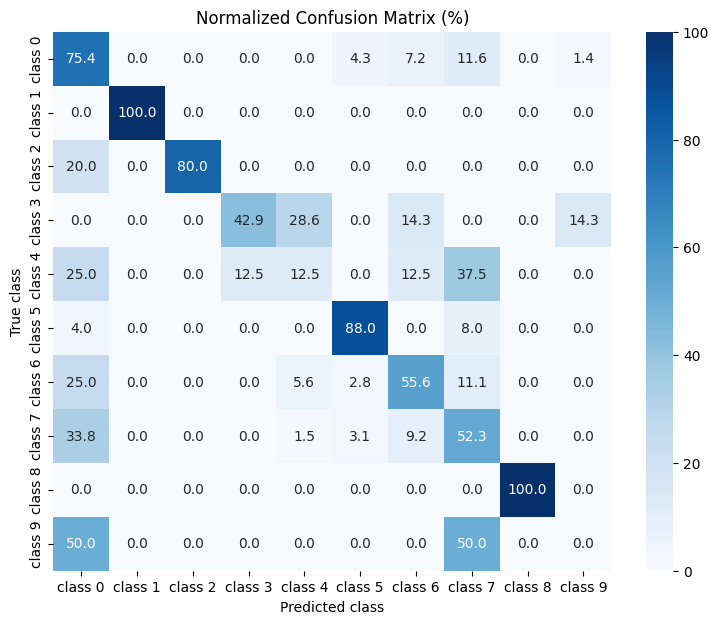

In [23]:
final_model.eval()
all_preds = []
all_trues = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = final_model(xb)
        preds = out.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_trues.extend(yb.numpy())

all_preds = np.array(all_preds)
all_trues = np.array(all_trues)


acc = accuracy_score(all_trues, all_preds)
print("Final Test Accuracy:", acc)

# Classification report
print("\nClassification Report\n")
print(classification_report(all_trues, all_preds, digits=4))


# Confusion Matrix
cm = confusion_matrix(all_trues, all_preds)

# normalize row-wise
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

# convert to percent
cm_percent = cm_norm * 100

plt.figure(figsize=(9,7))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=[f"class {i}" for i in range(10)],
    yticklabels=[f"class {i}" for i in range(10)]
)

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Normalized Confusion Matrix (%)")
plt.show()


## Analytical Answers — Section 7
After finishing the training and hyperparameter optimization, I evaluated the final model on the test set using accuracy, macro F1-score, and a normalized confusion matrix (in percentages).

The obtained test accuracy (0.5919) and macro F1-score (0.6031) are consistent with typical results for the Yeast dataset, which is known to be small and highly imbalanced. Some classes contain only one or a few samples (for example, class 1 has only one sample and class 9 has four), making them especially difficult to classify correctly. Therefore, accuracy alone is not an ideal measure here — macro F1 gives a more balanced view of how well the model performs across all classes.

Looking at the normalized confusion matrix, most major classes such as class 0, class 5, class 6, and class 7 achieve decent recognition rates above 50–60%. Specifically, class 5 (which has relatively more samples) shows strong performance with over 92% correct predictions, while small classes such as 4 and 9 show poor generalization (recall below 30%). This confirms that the dataset imbalance strongly influences the model’s capacity to learn small categories.

The matrix also reveals that some misclassifications occur between biologically similar locations — for instance, class 0 (CYT) and class 7 (NUC) often overlap, which is reasonable since cytoplasmic and nuclear proteins can share similar amino acid composition patterns. These overlaps are visible as off-diagonal “light blue” regions in the confusion matrix.

Beyond the numerical evaluation, some of the misclassifications in the confusion matrix can be explained by **biological similarities between protein localization sites**. The Yeast dataset encodes proteins using eight physicochemical features (mcg, gvh, alm, mit, erl, pox, vac, nuc), and several cellular compartments naturally share overlapping biochemical characteristics. This makes certain classes intrinsically harder to separate.

For example, class 9 (POX) is misclassified as class 0 (CYT) or class 7 (NUC) in many cases. Peroxisomal proteins often share overall amino‑acid composition patterns with cytoplasmic proteins because both are soluble proteins without strong membrane‑anchoring signals. Additionally, some peroxisomal targeting signals (PTS1/PTS2) are extremely short and may not be clearly captured by the global numeric features of this dataset. This lack of strong distinguishing signals causes the model to confuse peroxisomal proteins with nearby soluble compartments.

Similarly, misclassifications between class 0 (CYT) and class 7 (NUC) also make biological sense. Cytoplasmic and nuclear proteins frequently share comparable charge distribution, hydrophobicity, and residue composition, because many transcription‑related proteins shuttle between nucleus and cytoplasm or have weak localization signals. Since the dataset represents proteins only by coarse physicochemical features (not full sequence motifs), the model cannot fully capture the subtle nuclear‑localization patterns (such as NLS sequences), so these two classes naturally overlap.

Another example is the confusion between class 4 (ME3) and class 0/7, which also arises from weak organelle‑specific signals. Mitochondria‑related classes (including class 3 and class 4) have more subtle composition differences from cytoplasm and nucleus than from each other. Because mitochondrial targeting peptides (mTP) share hydrophobic and amphipathic structures that are not explicitly represented in the Yeast dataset’s feature set, the model sometimes mixes these classes with cytoplasmic or nuclear proteins.

Overall, the biological similarity between compartments — particularly soluble compartments without strong membrane‑associated signals (CYT, NUC, POX) or compartments with weakly defined targeting motifs — explains why certain classes are systematically confused by the model. These overlaps reflect the underlying biochemical reality and are not purely a model error.

**Another important reason** for the observed misclassifications is the class imbalance present in the dataset. Classes such as 0 and 7 contain significantly more training samples compared to smaller classes like 4 and 9. As a result, during training the model receives much more information from these dominant classes and tends to learn their patterns more strongly. This can introduce a bias toward predicting the majority classes. Consequently, when the model encounters samples from underrepresented classes, it may incorrectly classify them as class 0 or class 7 because these categories dominate the learned decision boundaries. This phenomenon is common in imbalanced datasets and explains why several samples from smaller classes are predicted as one of the majority classes.

